## Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from ifood.model import LGBMTrainer
from ifood.model import LGBMHyperparameterOptimizer
from optuna.visualization import plot_optimization_history, plot_param_importances as plot_param_importance
import seaborn as sns

from pathlib import Path
import json
sns.set_theme()

## Train

### Baseline

In [ ]:
features = [
    # Offer Params
    "time_since_test_start",
    "discount_value",
    "duration",
    "min_value",
    "offer_type",
    "web_channel",
    "mobile_channel",
    "email_channel",
    "social_channel",
    # Customer
    "age",
    "credit_card_limit",
    "account_age",
    # "age" removed by fairness 
]

default_params = {
    "n_estimators": 100,
    "learning_rate": 0.05,
    "verbose": -1,
}

trainer = LGBMTrainer(
    data_path = str(Path.cwd().parent / 'data' / 'processed'/ 'unified'),
    random_state=42,
    target='target',
    features=features,
    categorical_features=['offer_type'],
    lgbm_params=default_params
)
X_train, X_test, y_train, y_test = trainer.prepare_data()
model, metrics = trainer.train()

In [4]:
metrics

,train,test
rmse,53.413103,57.809371
r2,0.252756,0.085702
spearman_correlation,0.670434,0.630004


### Optimize with Optuna

In [ ]:
optimizer = LGBMHyperparameterOptimizer(trainer, n_trials=30)
study = optimizer.optimize()

In [6]:
print(f'Best RMSE (CV): {study.best_value:.4f}')
print("Best hyperparameters:")
print(json.dumps(study.best_params, indent=2))

Best RMSE (CV): 58.6576
Best hyperparameters:
{
  "n_estimators": 295,
  "learning_rate": 0.009651279804585714,
  "num_leaves": 74,
  "max_depth": 4,
  "min_child_samples": 36,
  "subsample": 0.9192935333529578,
  "colsample_bytree": 0.6201806831894504,
  "reg_alpha": 1.2722974438529106e-08,
  "reg_lambda": 8.80207501426475
}


In [7]:
plot_optimization_history(study)

In [8]:
plot_param_importance(study)

### Optimized

In [16]:
features = [
    # Offer Params
    "time_since_test_start",
    "discount_value",
    "duration",
    "min_value",
    "offer_type",
    "web_channel",
    "mobile_channel",
    "email_channel",
    "social_channel",
    # Customer
    "age",
    "credit_card_limit",
    "account_age",
    # "age" removed by fairness 
]

default_params = {
    "n_estimators": 295,
    "learning_rate": 0.009651279804585714,
    "num_leaves": 74,
    "max_depth": 4,
    "min_child_samples": 36,
    "subsample": 0.9192935333529578,
    "colsample_bytree": 0.6201806831894504,
    "reg_alpha": 1.2722974438529106e-08,
    "reg_lambda": 8.80207501426475
} 

trainer = LGBMTrainer(
    data_path = str(Path.cwd().parent / 'data' / 'processed'/ 'unified'),
    random_state=42,
    target='target',
    features=features,
    categorical_features=['offer_type'],
    lgbm_params=default_params
)
X_train, X_test, y_train, y_test = trainer.prepare_data()
model, metrics = trainer.train()

metrics

,train,test
rmse,53.413103,57.809371
r2,0.252756,0.085702
spearman_correlation,0.670434,0.630004


<Axes: xlabel='target', ylabel='Count'>

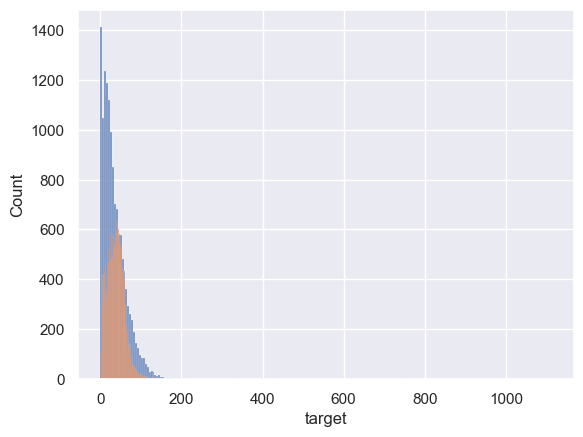

In [21]:
sns.histplot(y_train)
sns.histplot(model.predict(X_train))

<Axes: xlabel='target', ylabel='Count'>

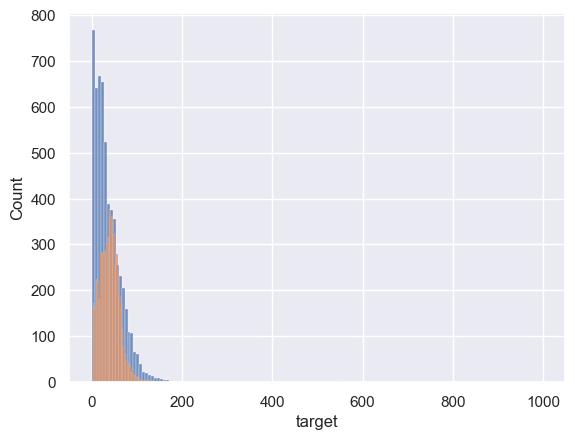

In [22]:
sns.histplot(y_test)
sns.histplot(model.predict(X_test))

<Axes: xlabel='target', ylabel='Count'>

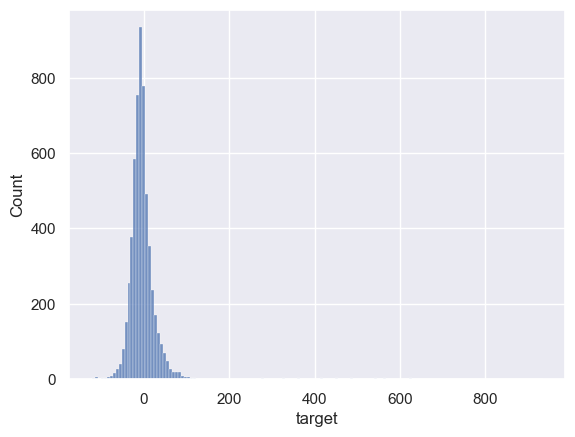

In [24]:
sns.histplot(y_test - model.predict(X_test))

### Shap

In [25]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)

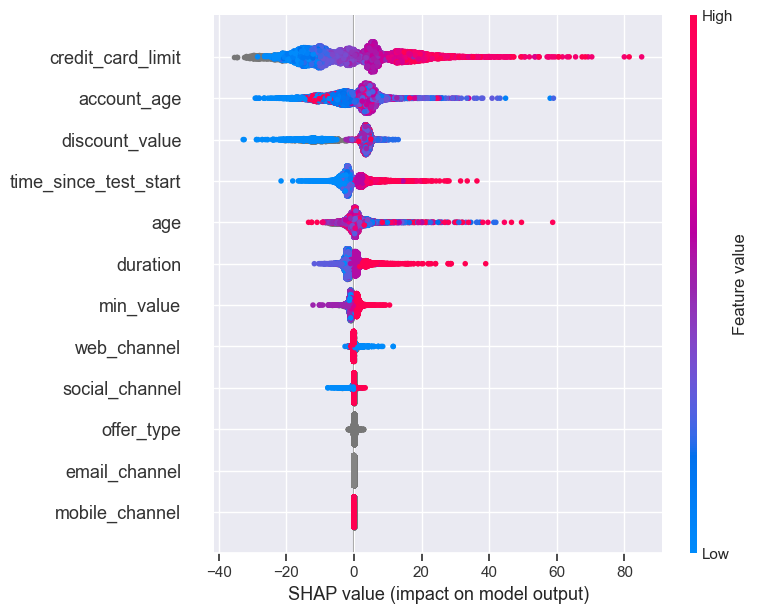

In [26]:
shap.summary_plot(shap_values, X_train)

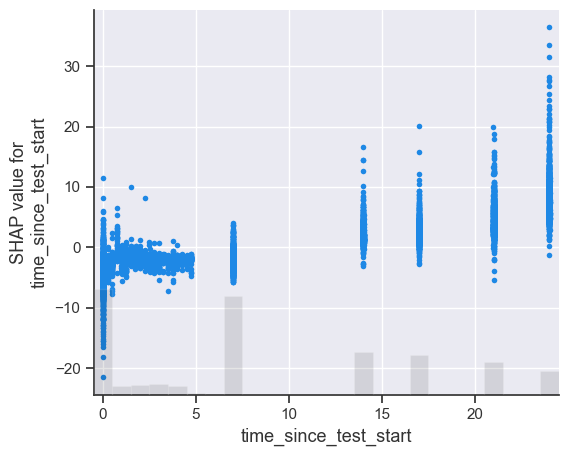

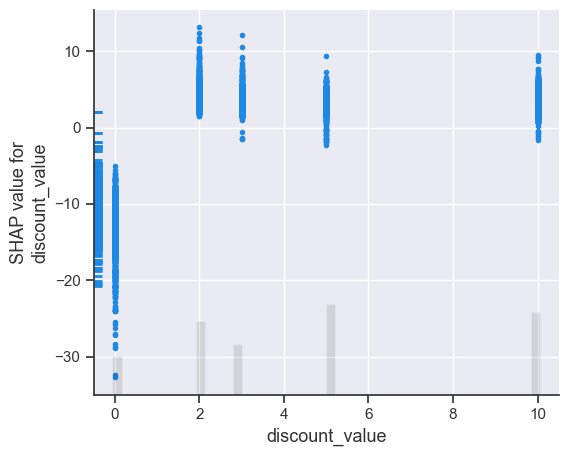

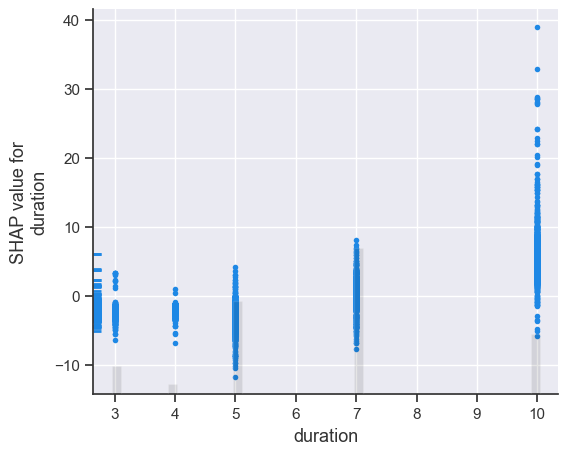

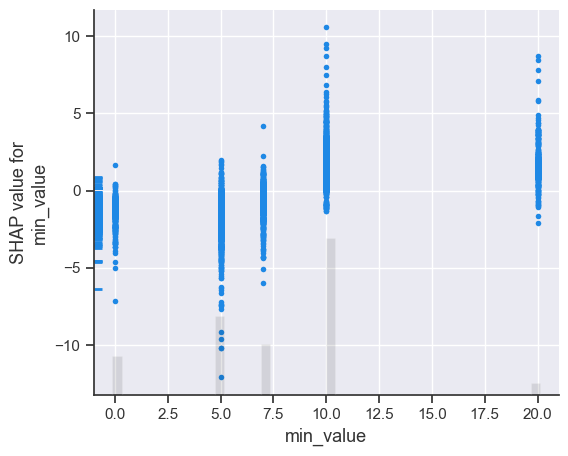

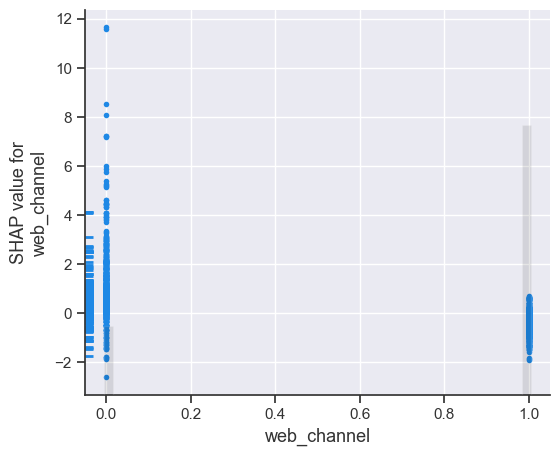

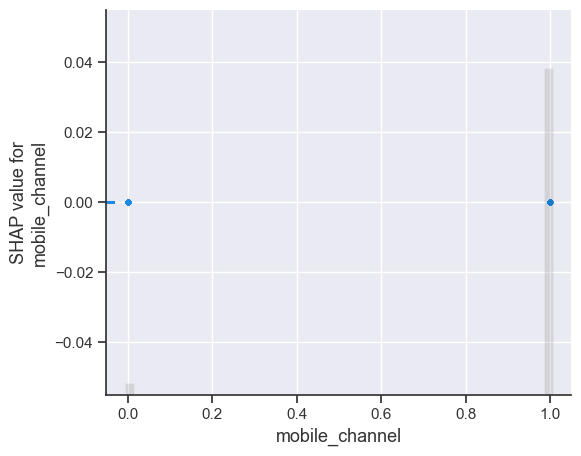

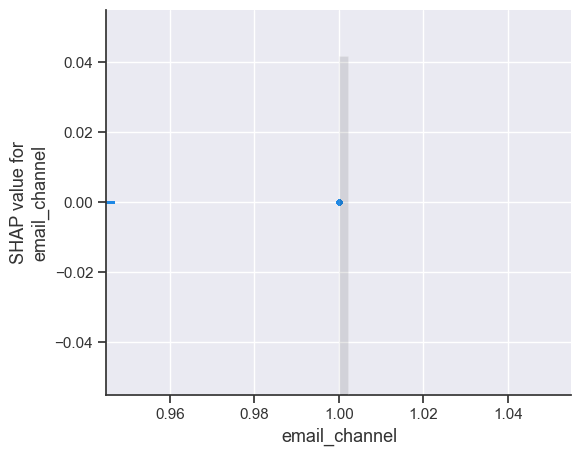

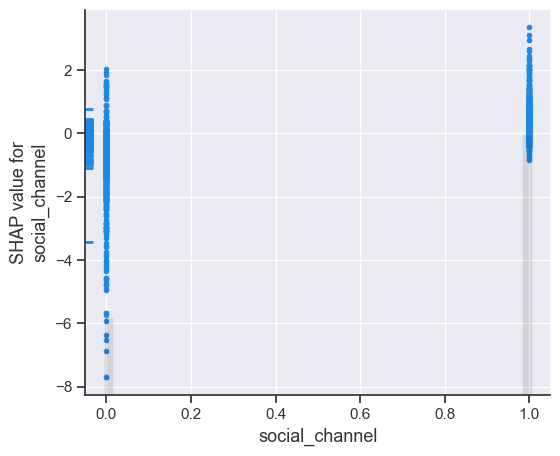

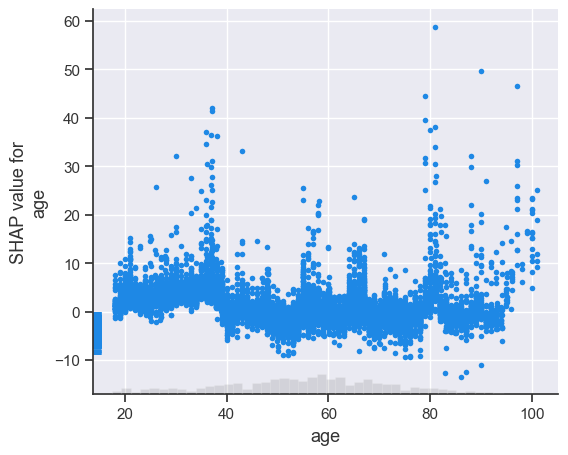

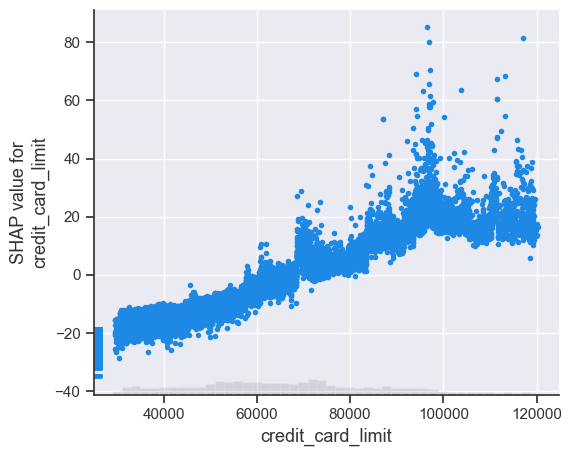

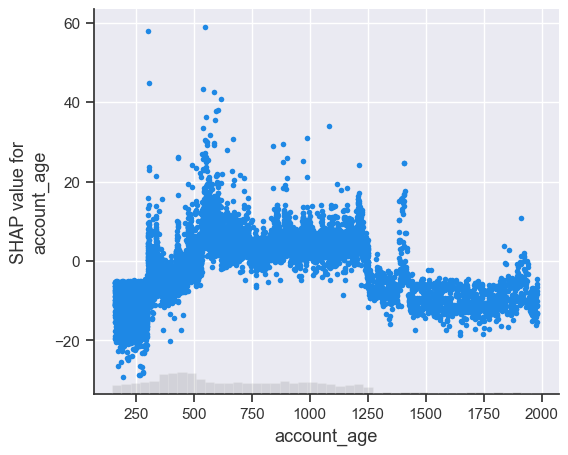

In [34]:
for name in X_train.columns:
    if name != "offer_type":
        shap.plots.scatter(shap_values[:, name])

## Results